# Imports & Functions

In [147]:
import pandas as pd
from pathlib import Path
from ydata_profiling import ProfileReport
# import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import data_loading  # Import the module instead of specific functions


reload(data_loading)  # Reload the module after making changes so that the kernel resets

# reference functions directly from the reloaded module
read_csv_to_dataframe = data_loading.read_csv_to_dataframe
read_txt_to_dataframe = data_loading.read_txt_to_dataframe

In [148]:
"""
Expands the categories in a given column of a DataFrame into separate binary columns.

Parameters:
- df: pandas.DataFrame, the DataFrame to modify.
- column_name: str, the name of the column to expand.
"""
def expand_categories_in_column(df, column_name):

    # create set of unique entries from a string based on splitting at ", "
    unique_categories = set()
    df[column_name].dropna().apply(lambda x: unique_categories.update(set(x.split(', '))))

    # init dict to hold new columns
    new_cols = {}
    
    for category in unique_categories:
        # add col name as there are duplicates across different cols
        # remove spaces and commas from col name
        valid_category_name = column_name + "_" + category.lower().replace(' ', '_').replace(',', '')
        
        # Instead of modifying df directly, create and store the new column in new_cols
        mask = df[column_name].fillna('').str.contains(category, regex=False, na=False)
        new_cols[valid_category_name] = mask.astype(int)

    # Create a new df from the new_cols dictionary
    new_columns_df = pd.DataFrame(new_cols, index=df.index)
    
    # Concatenate the new columns to the original DataFrame and drop original col
    df = pd.concat([df, new_columns_df], axis=1)
    df = df.drop(columns={column_name})

    return df

In [149]:
## preprocessing script for logistic regressions dataframes
## based on test_df
def preprocess_df(test_df, unique_col):

    # make a copy, take the appropriate cols, expand accordingly
    df_copy = test_df.copy()
    df_copy = df_copy[['substance carried', unique_col]]
    print(df_copy.count())
    
    df_copy[unique_col] = df_copy[unique_col].str.lower()
    df_copy = expand_categories_in_column(df_copy, unique_col)
    df_copy.drop(columns=[unique_col], inplace=True)
    
    return df_copy

In [150]:
# correlation matrix and dropping highly-correlated pairs for logistic regression
def handle_correlation_and_drop_columns(test_df):
    # Correlation matrix and identify pairs with correlation > 0.8 (and less than 1)
    corr_matrix = test_df.corr()
    high_corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
    high_corr_pairs = high_corr_pairs[(abs(high_corr_pairs) > 0.8) & (high_corr_pairs != 1)]
    
    # Identify columns to drop based on correlations > 0.8
    threshold = 0.8
    to_drop = set()
    for (col1, col2), corr in high_corr_pairs.items():
        if corr > threshold:
            # drop col with less entries
            sum_col1 = test_df[col1].sum()
            sum_col2 = test_df[col2].sum()
            if sum_col1 < sum_col2:
                to_drop.add(col1)
            else:
                to_drop.add(col2)
    
    # Drop cols from above from dataframe
    reduced_df = test_df.drop(columns=list(to_drop))
    return reduced_df

In [151]:
# logistic regression for qualitative cols
def fit_and_evaluate_logistic_regression(test_df):
    # 'substance carried' is the target variable
    X = test_df.drop(['substance carried'], axis=1)  # Features
    y = test_df['substance carried']  # Target
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Create and fit the logistic regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    # Predictions and evaluation
    y_pred = model.predict(X_test)
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred), "\n")
    print("Classification report:\n", classification_report(y_test, y_pred), "\n")
    
    # Coefficients
    coefficients = pd.DataFrame(model.coef_.flatten(), index=X.columns, columns=['Coefficient'])
    sorted_coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
    print("Sorted coefficients:\n", sorted_coefficients, "\n")
    
    return model

In [152]:
# random forest
def fit_and_evaluate_random_forest(test_df):
    X = test_df.drop(['substance carried'], axis=1)
    y = test_df['substance carried']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    print("Random Forest Classifier:")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return rf_model

In [153]:
# decision tree
def fit_and_evaluate_decision_tree(test_df):
    X = test_df.drop(['substance carried'], axis=1)
    y = test_df['substance carried']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)

    y_pred = dt_model.predict(X_test)
    print("Decision Tree Classifier:")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return dt_model

In [154]:
# SVM
def fit_and_evaluate_svm(test_df):
    X = test_df.drop(['substance carried'], axis=1)
    y = test_df['substance carried']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    svm_model = SVC(kernel='linear')
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)
    print("Support Vector Machine Classifier:")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return svm_model

# Load in dataset A

In [155]:
## making file path imports more robust

# get directory of current file
current_script_directory = Path.cwd()

# Construct path to data files given relative location
cad_string = current_script_directory / "../data/raw/canada/"
cad_data = cad_string / "pipeline-incidents-comprehensive-data.csv"

# read data into dataframes
CAD_data_raw = read_csv_to_dataframe(cad_data)

File at '/Users/cameronmackinnon/PD/Winter 2024 Job Hunt/Companies/Validere/crude_oil_accidents/src/../data/raw/canada/pipeline-incidents-comprehensive-data.csv' successfully read into a DataFrame.


# Data Cleaning

### Data Dictionary

In [156]:
# make deep copy for cleaned df
CAD_data_cleaned = CAD_data_raw.copy()

# looked at data dictionary for columns that could be relevant to inherent properties of substance / pipeline specifications / cause of incident
# want to analyze this subset for trends/correlations
## data dict and data don't line up so needed to manually change some; labelled with "## different"
subset_columns = [
"pipeline or facility type",
"pipeline or facility equipment involved",
"rupture",
"incident types", ## different
"conditions that resulted in the operation beyond limits",
"pipeline outside diameter (nps)",
"pipeline length (km)",
"substance carried",
"released substance type",
"facility type", ## different
"facility latitude",
"facility longitude",
"longitude",
"latitude",
"nominal pipe size",
"material",
"material grade",
"schedule",
"design wall thickness (mm)",
"custom design wall thickness (mm)",
"actual wall thickness (mm)",
"licensed maximum operating pressure (kpa)",
"actual operating pressure at time of failure (kpa)",
"year of manufacture",
"most recent cathodic protection reading at incident site (mv vs. cu/cuso4)",
"weld type",
"seam type",
"coating location",
"coating type",
"coating condition",
"application method",
"year when the coating was applied",
"insulation installed",
"detailed what happened", ## diff
"what happened category", ## diff
"detailed why it happened", ## diff
"why it happened category" ## diff
]

# Taking the subset
CAD_data_cleaned = CAD_data_cleaned[subset_columns]

### Substance carried / released substance

In [157]:
## 3 substance-based columns - if they're all empty/NA then we'll drop the rows as these don't really help us
## EDIT: "substance" and "released substance type" are identical cols so removed substance
CAD_data_cleaned = CAD_data_cleaned.loc[~((CAD_data_cleaned['substance carried'].isna()) & (CAD_data_cleaned['released substance type'].isna()))]

In [158]:
## lots of na's in substance carried col - try to imputate data as best as we can

## OPTION 1: substance carried contains crude oil, released substance does not; released substance = lube oil, drilling fluid, natural gas liquids, diesel fuel, condensate
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].str.contains('Crude Oil')) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil')==False)][['released substance type', 'substance carried']].drop_duplicates()


,released substance type,substance carried
153,Lube Oil,"Crude Oil, Crude Oil Sour Heavy, Crude Oil Sou..."
232,Drilling Fluid,Crude Oil
284,Natural Gas Liquids,Crude Oil
349,Natural Gas Liquids,"Condensate, Crude Oil, Natural Gas Liquids"
593,Drilling Fluid,"Crude Oil, Crude Oil Sour Heavy, Crude Oil Sou..."
1050,Natural Gas - Sweet,Crude Oil
1160,Diesel Fuel,"Crude Oil, Crude Oil Sour Heavy, Crude Oil Sou..."
1487,Condensate,Crude Oil
1838,Hydraulic Fluid,Crude Oil


In [159]:
## OPTION 2: substance carried contains crude oil, released subsance does too
## OBSERVATION: released substance type sometimes is more specific (sour vs. sweet) than substance carried
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].str.contains('Crude Oil')) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil'))][['released substance type', 'substance carried']].drop_duplicates()


,released substance type,substance carried
10,Crude Oil - Sour,Crude Oil
29,Crude Oil - Sweet,Crude Oil
183,Crude Oil - Synthetic,Crude Oil
196,Crude Oil - Sweet,"Crude Oil, Crude Oil Sour Heavy, Crude Oil Sou..."


In [160]:
## OPTION 3: substance carried doesn't contain crude oil, released substance does? 
## NO RESULTS
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].str.contains('Crude Oil')==False) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil'))][['released substance type', 'substance carried']].drop_duplicates()

,released substance type,substance carried


In [161]:
## OPTION 4: substance carried doesn't contain crude oil, released substance doesn't either
## HAPPENS A LOT - and the released substance type looks similar as if the substance carried was crude oil
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].str.contains('Crude Oil')==False) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil')==False)][['released substance type', 'substance carried']].drop_duplicates()

,released substance type,substance carried
4,Natural Gas - Sweet,Natural Gas
14,Jet Fuel,"not applicable, Refined Products-Aviation, Ref..."
16,Natural Gas - Sweet,"Natural Gas, Natural Gas Sweet"
17,Water,White Water
31,Natural Gas - Sour,Natural Gas Sour
79,Natural Gas - Sweet,Natural Gas Sweet
87,Pulp slurry,Sulfite Pulp Slurry
101,Mixed HVP Hydrocarbons,Natural Gas Sweet
281,Contaminated Water,"Natural Gas Sour, Natural Gas Sweet, not appli..."
282,Propane,Natural Gas Sour


In [162]:
# option 5 - substance carried is na, but released substance contains crude oil
## Can confidently change the substance carried to crude oil based on results from option #3
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].isna()) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil'))][['released substance type', 'substance carried']].drop_duplicates()
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].isna()) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil')), 'substance carried'] = 'Crude Oil'

In [163]:
# option 6 - substance carried is na, released substance does not contain crude oil
## change substance carried to NOT crude oil IFF the released substance type has 0% change of appearing in crude oil (source of list: chatgpt)
not_in_pipeline_crude_oil = [
    "Potassium Hydroxide (caustic solution)",
    "Sulphur Dioxide",
    "Water",
    "Potassium Carbonate",
    "Contaminated Water",
    "Waste Oil",
    "Amine",
    "Produced Water",
    "Glycol",
    "Pulp slurry"
]
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].isna()) & (CAD_data_cleaned['released substance type'].str.contains('Crude Oil')==False)][['released substance type', 'substance carried']].drop_duplicates()
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].isna()) & (CAD_data_cleaned['released substance type'].isin(not_in_pipeline_crude_oil)), 'substance carried'] = 'NOT crude oil'



In [164]:
# OPTION 7/8 - released substance type is na; can't assume what was released (if anything); ignore! 
CAD_data_cleaned.loc[(CAD_data_cleaned['substance carried'].str.contains('Crude Oil')) & (CAD_data_cleaned['released substance type'].isna())][['released substance type', 'substance carried']].drop_duplicates()

,released substance type,substance carried
22,NaN,Crude Oil
24,NaN,"Crude Oil, Crude Oil Sour Heavy, Crude Oil Sou..."
1732,NaN,"Condensate, Crude Oil"


In [165]:
# still left with lots of records where substance carried is N/A
# sadly have to drop these as it's going to be our target/key attribute and we cannot imputate any further
print("dropping {} rows as they don't have a substance carried".format(len(CAD_data_cleaned.loc[CAD_data_cleaned['substance carried'].isna()])))
CAD_data_cleaned = CAD_data_cleaned.loc[CAD_data_cleaned['substance carried'].isna()==False]

dropping 396 rows as they don't have a substance carried


In [166]:
## want to update substance type so that it's either "Crude" or "not crude" so that we can more easily identify trends

# LET's map non crude to 0 and crude to 1
CAD_data_cleaned.loc[CAD_data_cleaned['substance carried'].astype(str).str.contains('Crude Oil')==False, 'substance carried'] = 0

## let's also combine the crude oils (crude vs. crude - sour,heavy,light,sweet)
CAD_data_cleaned.loc[CAD_data_cleaned['substance carried'] != 0 , 'substance carried'] = 1

### Dropping cols with less than 50% of values

In [167]:
## WANT to work with attributes that have decent data, therefore going to: 
# drop columns that have more than x percentage of na's
# can play around with this value to see how it affects results
threshold = 0.5
CAD_data_cleaned = CAD_data_cleaned.loc[:, CAD_data_cleaned.isnull().mean() < 0.5]

# remaining categorical cols
categorical_cols = CAD_data_cleaned.select_dtypes(include=['object']).columns
categorical_cols

Index(['pipeline or facility type', 'pipeline or facility equipment involved',
       'rupture', 'incident types', 'pipeline outside diameter (nps)',
       'substance carried', 'insulation installed', 'detailed what happened',
       'what happened category', 'detailed why it happened',
       'why it happened category'],
      dtype='object')

In [168]:
CAD_data_cleaned.head(2)

,pipeline or facility type,pipeline or facility equipment involved,rupture,incident types,pipeline outside diameter (nps),pipeline length (km),substance carried,longitude,latitude,insulation installed,detailed what happened,what happened category,detailed why it happened,why it happened category
4,NaN,Yes,No,Release of Substance,1219.20000000,943.293210,0,-108.36036,50.57578,No,"Damage or deterioration mechanism, Constructio...",Defect and Deterioration,"Job or system factors, Inadequate work standar...",Standards and Procedures
10,NaN,Yes,No,Release of Substance,"1219.00000000, 864.00000000, 914.00000000",1248.909872,1,-109.80493,52.13984,No,"Damage or deterioration mechanism, Equipment, ...",Equipment Failure,"Job or system factors, Inadequate leadership a...",Inadequate Supervision


### Cleaning numeric

In [169]:
# only going to take first of pipeline outside diameter values (sometimes provided in different units)
CAD_data_cleaned['pipeline outside diameter (nps)'] = CAD_data_cleaned['pipeline outside diameter (nps)'].str.split(',').str[0].astype(float).fillna(0)

# fill empty length values with 0
CAD_data_cleaned['pipeline length (km)'] = CAD_data_cleaned['pipeline length (km)'].astype(float).fillna(0)

## longitude & latitude look good

### Categorical to Numeric

In [170]:
## Before exploring the data, want to convert any string-based/categorical columns to binary or numeric
pipeline_map = {'Transmission': 1, 'Processing':2, 'Distribution':3, 'Gathering':4}
CAD_data_cleaned['pipeline or facility type'] = CAD_data_cleaned['pipeline or facility type'].map(pipeline_map).fillna(0)
CAD_data_cleaned['pipeline or facility type'].unique()

array([0., 1., 2., 3., 4.])

In [171]:
## Generic binary mapping
binary_map = {'Yes': 1, 'No':0}

In [172]:
# pipeline or facility equipment
CAD_data_cleaned['pipeline or facility equipment involved'] = CAD_data_cleaned['pipeline or facility equipment involved'].map(binary_map)
CAD_data_cleaned['pipeline or facility equipment involved'].unique()

array([1, 0])

In [173]:
# rupture
CAD_data_cleaned['rupture'] = CAD_data_cleaned['rupture'].map(binary_map)
CAD_data_cleaned['rupture'].unique()

array([0, 1])

In [174]:
## insulation installed - all equal no so let's just drop; not going to give extra info
CAD_data_cleaned.drop(columns=['insulation installed'], inplace=True)

### Descriptive cols

In [175]:
## UPDATE ON incident types, detailed what happened, what happened category, detailed why it happened, and why it happened category:

## We really only care about the incidents that were caused/could have been related to the actual substance being carried/released
## THEREFORE - before we expand the columns below, let's FILTER for only the incidents that could have related to the properties of the substance
## Physical properties - heavier oils could take more pressure to push and could also increase wear and tear. Look for: wear and tear, material weardown, pressure, etc.
## Chemical properties - corrosion/cracking, fires due to flammability of substance

## let's work 1-by-1 so that it removes entries (and therefore work) as we go
## starting with the columns that have the least number of classifications - incident types and what happened category

In [176]:
## incident types
## REMOVING: ["Adverse Environmental Effects", "Operation Beyond Design Limits"]
inc_type_drop = ["Adverse Environmental Effects", "Operation Beyond Design Limits"]
CAD_data_cleaned = CAD_data_cleaned.loc[CAD_data_cleaned['incident types'].isin(inc_type_drop)==False]

In [177]:
## what happened category
## REMOVING: ["External Interference", "Incorrect Operation", "Natural Force Damage"]
## ACTUALLY: since its a combination of all the options - let's only keep entries that have at least one of the categories that we care about
## WANT TO KEEP: ["Corrosion and Cracking", "Defect and Deterioration", "Equipment Failure", "Other Causes", "To be determined"]

what_happ_keep = ["Corrosion and Cracking", "Defect and Deterioration", "Equipment Failure", "Other Causes", "To be determined"]
CAD_data_cleaned = CAD_data_cleaned.loc[CAD_data_cleaned['what happened category'].apply(lambda x: any(item in x for item in what_happ_keep))]

In [178]:
len(CAD_data_cleaned)
## already below 400 so don't want to drop many more

361

In [179]:
## ASSUMPTION: DOMAIN KNOWLEDGE

In [180]:
## detailed what happened
# every entry includes "damage or deterioration mechanism" or "substandard acts" as a kind of header/categorization
# we don't care about the substandard acts, but we do care about the damage or deterioration
# so let's extract this portion of the string and then ignore the rest

CAD_data_cleaned['detailed what happened'] = CAD_data_cleaned['detailed what happened'].astype(str)

# extract damage portion of string
damage_regex = r"Damage or deterioration mechanism, ([^;]+)"

# clean up matches by removing the original phrase and stripping
def cleanup(matches, phrase):
    cleaned = [match.replace(phrase, '').strip() for match in matches]
    return ';'.join(cleaned)

# Find all occurrences, clean them up, and join with a semi-colon
CAD_data_cleaned['damage_or_deterioration'] = CAD_data_cleaned['detailed what happened'].str.findall(damage_regex).apply(lambda matches: cleanup(matches, "Damage or deterioration mechanism, "))

# drop orig col
CAD_data_cleaned.drop(columns={'detailed what happened'}, inplace=True)

In [181]:
## why it happened
## really hard to figure out which of these to remove.
## e.g., "failure in communication" maps to three corrosion events.
## siimilarly, "Human Factors" maps to some deterioration events and some equipment failures
## THEREFORE - let's keep all for now

In [182]:
## detailed why it happened
## similar to above; not going to filter out any

In [183]:
## REASONING - one-hot BECAUSE multiple options

## incident types - sometimes include multiple options (e.g., release of substance and operation beyond design limits)
## let's expand the unique entries into binary columns and mark them as 1 or 0 based on whether they happened
## (and then drop the original incident types column)
CAD_data_cleaned = expand_categories_in_column(CAD_data_cleaned, 'incident types')

# can do the same for what happened category as it has minimal entries
## reminder that "natural force" will still exist (among others) as they happened in tandem with corrosion, etc.
CAD_data_cleaned = expand_categories_in_column(CAD_data_cleaned, 'what happened category')

In [184]:
## detailed what happened - now "damage_or_deterioration" - unsure if we should expand this? 
# sorted(CAD_data_cleaned['damage_or_deterioration'].astype(str).unique())

## same thought process for "detailed why it happened" and "why it happened category"
## too many options and may be providing repetitive data
CAD_data_cleaned.drop(columns={'damage_or_deterioration', 'detailed why it happened', 'why it happened category'}, inplace=True)

# CAD_data_cleaned = expand_categories_in_column(CAD_data_cleaned, 'damage_or_deterioration')
# CAD_data_cleaned = expand_categories_in_column(CAD_data_cleaned, 'detailed why it happened')
# CAD_data_cleaned = expand_categories_in_column(CAD_data_cleaned, 'why it happened category')

# Data Exploration

In [185]:
## GENERATE a profiling report to identify any preliminary trends/issues in the data

# drop duplicates (discussed in results below)
all_cad = CAD_data_cleaned.copy()
all_cad = all_cad.drop_duplicates(keep='first')

# Define the path to the report file
report_path = Path("../reports/dataset_A_all_cad_profile_report.html")

# only generate report if it doesn't already exist
if not report_path.exists():
    all_cad_profile = ProfileReport(all_cad, title="All CAD data Profiling Report", explorative=True)
    all_cad_profile.to_file(report_path)
else:
    print("Report already exists.")

## RESULTS
# duplicate rows - manual inspection of data shows that these were identical incidents reported by different people.
# let's drop duplicate and keep first even though some of them have different attribute values
# doing this above and then rerunning
    
## HEATMAP / CORRELATION
# releases of substances are highly correlated with fires
# pipeline length is highly correlated with pipeline outside diameter
## SUBSTANCE CARRIED is highly correlated with latitude (and pipeline length)
# corrosion and cracking highly correlated with equipment failure


Report already exists.


In [186]:
# SPLIT df into substance carried contains crude oil or does not so that we can get quantitative descriptive statistics (qualitative in html file)
crude_cad = all_cad.copy()
crude_cad = crude_cad.loc[crude_cad['substance carried'] == 1]

non_crude_cad = all_cad.copy()
non_crude_cad = non_crude_cad.loc[non_crude_cad['substance carried'] == 0]

In [187]:
non_crude_cad.describe()

,pipeline or facility type,pipeline or facility equipment involved,rupture,pipeline outside diameter (nps),pipeline length (km),longitude,latitude,incident types_adverse_environmental_effects,incident types_serious_injury_(cer_or_tsb),incident types_fire,incident types_release_of_substance,incident types_explosion,what happened category_other_causes,what happened category_natural_force_damage,what happened category_to_be_determined,what happened category_external_interference,what happened category_incorrect_operation,what happened category_defect_and_deterioration,what happened category_equipment_failure,what happened category_corrosion_and_cracking
count,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.00000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000
mean,0.949640,0.852518,0.043165,510.826619,614.477352,-100.373835,51.306148,0.021583,0.003597,0.154676,0.852518,0.014388,0.05036,0.014388,0.017986,0.122302,0.125899,0.208633,0.399281,0.366906
std,0.885697,0.355225,0.203596,323.226460,974.054922,21.623142,4.315991,0.145579,0.059976,0.362248,0.355225,0.119301,0.21908,0.119301,0.133139,0.328225,0.332334,0.407064,0.490634,0.482830
min,0.000000,0.000000,0.000000,0.000000,0.000000,-122.689900,42.287869,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,273.100000,16.596023,-118.628477,47.361386,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,508.000000,112.455223,-111.685646,51.669793,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,762.000000,574.880799,-79.498208,55.294618,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4.000000,1.000000,1.000000,1362.400000,3393.426420,-61.612676,58.655000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [188]:
crude_cad.describe()

,pipeline or facility type,pipeline or facility equipment involved,rupture,pipeline outside diameter (nps),pipeline length (km),longitude,latitude,incident types_adverse_environmental_effects,incident types_serious_injury_(cer_or_tsb),incident types_fire,incident types_release_of_substance,incident types_explosion,what happened category_other_causes,what happened category_natural_force_damage,what happened category_to_be_determined,what happened category_external_interference,what happened category_incorrect_operation,what happened category_defect_and_deterioration,what happened category_equipment_failure,what happened category_corrosion_and_cracking
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.00000,74.000000,74.000000,74.000000
mean,0.851351,0.743243,0.013514,521.231081,753.365676,-111.154232,51.074436,0.013514,0.013514,0.310811,0.635135,0.054054,0.081081,0.040541,0.013514,0.310811,0.22973,0.148649,0.689189,0.162162
std,0.974784,0.439826,0.116248,432.604686,642.472629,9.883003,2.807402,0.116248,0.116248,0.465985,0.484678,0.227668,0.274823,0.198569,0.116248,0.465985,0.42353,0.358170,0.465985,0.371116
min,0.000000,0.000000,0.000000,0.000000,0.000000,-122.950276,42.952425,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.250000,0.000000,0.000000,0.000000,-120.233745,49.268490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,559.000000,946.159155,-113.351635,50.483397,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,0.000000,762.000000,1255.999121,-104.593327,53.357191,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000
max,4.000000,1.000000,1.000000,1219.000000,2334.948756,-77.929450,61.861680,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


# ML Models

### Preprocess / correlation matrix

In [189]:
# correlation/preprocessing
all_cad_red = handle_correlation_and_drop_columns(all_cad)
all_cad_red['substance carried'] = all_cad_red['substance carried'].astype(int)

### Logistic Regression

In [190]:
print("Results:")
model_2 = fit_and_evaluate_logistic_regression(all_cad_red)

Results:
Confusion matrix:
 [[79  4]
 [17  6]] 

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.95      0.88        83
           1       0.60      0.26      0.36        23

    accuracy                           0.80       106
   macro avg       0.71      0.61      0.62       106
weighted avg       0.77      0.80      0.77       106
 

Sorted coefficients:
                                                  Coefficient
what happened category_equipment_failure            0.761525
what happened category_external_interference        0.592937
what happened category_natural_force_damage         0.577876
what happened category_to_be_determined             0.531804
what happened category_other_causes                 0.525472
incident types_explosion                            0.348449
incident types_serious_injury_(cer_or_tsb)          0.262416
pipeline or facility equipment involved             0.172665
pipeline length (km)       

/Users/cameronmackinnon/PD/Winter 2024 Job Hunt/Companies/Validere/crude_oil_accidents/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [191]:
# Apply the Random Forest model
rf_model = fit_and_evaluate_random_forest(all_cad_red)

Random Forest Classifier:
Confusion matrix:
 [[83  0]
 [ 5 18]]
Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        83
           1       1.00      0.78      0.88        23

    accuracy                           0.95       106
   macro avg       0.97      0.89      0.92       106
weighted avg       0.96      0.95      0.95       106



In [192]:
# Apply the Decision Tree model
dt_model = fit_and_evaluate_decision_tree(all_cad_red)

Decision Tree Classifier:
Confusion matrix:
 [[82  1]
 [ 4 19]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        83
           1       0.95      0.83      0.88        23

    accuracy                           0.95       106
   macro avg       0.95      0.91      0.93       106
weighted avg       0.95      0.95      0.95       106



In [193]:
# Apply the SVM model
svm_model = fit_and_evaluate_svm(all_cad_red)

Support Vector Machine Classifier:
Confusion matrix:
 [[77  6]
 [17  6]]
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        83
           1       0.50      0.26      0.34        23

    accuracy                           0.78       106
   macro avg       0.66      0.59      0.61       106
weighted avg       0.75      0.78      0.76       106



### conclusions

#### Logistic Regression

In [194]:
## confusion matrix
# TN: 77; FP: 6; FN: 16; TP: 7

## Classification report
## Focusing on precision, recall, and overall accuracy

## Accuracy = 0.79; not horrible

## Crude Oil (1)
# Precision = 0.54; 54% correct when predict crude oil
# Recall = 0.30; only identified 30% of all crude oil instances

## Not Crude Oil (0)
# Precision = 0.83; 83% correct when selecting not crude oil
# Recall = 0.93; correctly identified 93% of all not crude oil instances

## COULD BE because of imbalance in dataset (~2x as many not crude oil as crude oil records)

## Coefficients
# similar coefficients predicting crude vs. not crude; given domain knowledge they do not seem to be especially relevant


## Conclusion
# good at predicting not crude oil, not good at predicting crude oil
# we could conclude that there are potentially inherent differences in not crude oil vs. crude oil accidents
## and therefore further investigation into their differences is warranted

## Future investigation
## look into specific attributes contributing to NOT crude oil incidents to determine why these attributes are more pronounced than those of crude oil
## look into crude oil/not crude oil vs. NON-incidents to determine what properties of the substances are causing the accidents in the first place
## feature engineering - removing less important attributes based on domain knowledge; aggregating attributes if possible
## expanding dataset by concating other relevant data files


#### Random Forest, Decision Tree, SVM

In [195]:
## random forest and decision tree performed exceptionally well - 95% accuracy; both tree-based models
## still better precision/recall at predicting non crude oil, but massive improvement on crude oil. 
## this implies that there are distinguishable characteristics in crude oil incidents. 

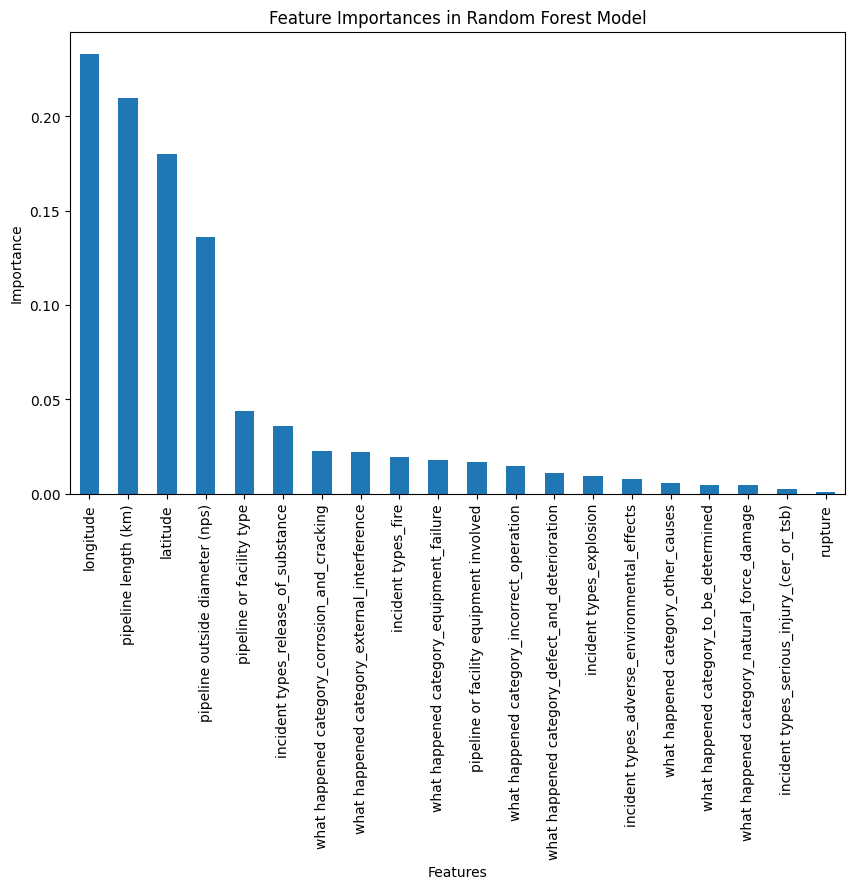

In [196]:
## feature importance analysis for RF

feature_importances = rf_model.feature_importances_

# create a series with feature names and their importance
features = pd.Series(feature_importances, index=all_cad_red.drop(['substance carried'], axis=1).columns)

# sort the features by importance
features_sorted = features.sort_values(ascending=False)

# plot bar chart
plt.figure(figsize=(10, 6))
features_sorted.plot(kind='bar')
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

## RESULTS
# sadly, longitude and latitude are two of the most important features in predicting crude oil vs. not crude oil
## this simply implies that crude oil pipelines exist at different locations than non-crude oil pipelines and therefore that's where the accidents are
## the same logic could be applied to pipeline length and outside diameter

## next steps
## drop these 2 columns and try running again

In [197]:
# drop lat and long, pipeline length and diameter
cad_without_location = all_cad_red.copy()
cad_without_location.drop(columns={'latitude', 'longitude', 'pipeline length (km)', 'pipeline outside diameter (nps)'}, inplace=True)

# run RF again
rf_model_without_location = fit_and_evaluate_random_forest(cad_without_location)

Random Forest Classifier:
Confusion matrix:
 [[79  4]
 [20  3]]
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87        83
           1       0.43      0.13      0.20        23

    accuracy                           0.77       106
   macro avg       0.61      0.54      0.53       106
weighted avg       0.72      0.77      0.72       106



In [ ]:
## this drops our accuracy to 77%, which essentially brings us back to the same conclusion as our original logistic regression model. 

# unused code

In [92]:
## ERROR - i originally thought the crude oils were separated - i.e., crude oil sour, crude oil sweet, etc.
## but it's actually all or nothing, i.e., crude oil OR crude oil sour, sweet, heavy, light
## so this sadly doesn't help our analysis

In [93]:
# ## START with cleaned dataframe
# cad_crude = CAD_data_cleaned.copy()
# #cad_crude['substance carried'].unique()

# # only want to look at crude oil incidents
# cad_crude = cad_crude.loc[(cad_crude['substance carried'].str.contains('Crude Oil')) | (cad_crude['released substance type'].str.contains('Crude Oil'))]

# # now let's extract the specifications (sour, sweet, heavy, light) into other columns so they're easier to deal with

# #cad_crude[['substance carried', 'released substance type']].drop_duplicates()
# cad_crude['substance carried'].unique()